In [ ]:
#### Figure 1a - Mock heatmap

/tmp/ipykernel_1503355/2987150122.py:101: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{int(x/1000000)}" for x in ax.get_xticks()],fontsize=13)
/tmp/ipykernel_1503355/2987150122.py:102: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{int(y/1000000)}" for y in ax.get_yticks()],fontsize=13)


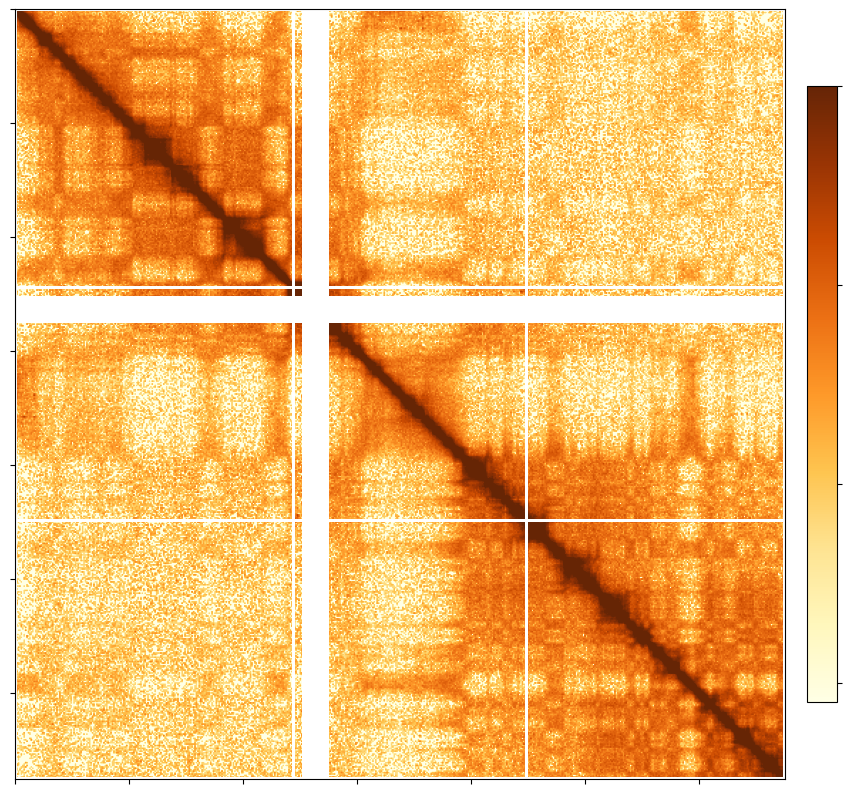

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import gridspec
from matplotlib import colors

import os
import re
import numpy as np
import pandas as pd
import cooler
import sys

cool_name = 'DL-20250326-LCHCSeq-K562-2mPD-Mock-R1-T1__hg38.hg38.exclude1kb.1000.mcool'
cool_path = '/MyPath/'

# resolution ...
binsize = 250_000
cooler_name_res = f"{cool_name}::/resolutions/{binsize}"
cooler_path_name = os.path.join(cool_path, cooler_name_res)

clr = cooler.Cooler(cooler_path_name)

# getting a symmetric region:
ucsc_region = "chr11"
#chrom = ucsc_region.split(':')[0]
#start = ucsc_region.split(':')[1].split("-")[0]
#end = ucsc_region.split(':')[1].split("-")[1]
matrix = clr.matrix(balance=True).fetch(ucsc_region)

# what's the dynamic range of the matrix,
# i.e. minimal and maxmum values ...
mmin = 0.00000008
mmax = 0.8
# we use nanmin/max to ignore NaNs in the matrix

# x-axis is basically your colorbar ...
logbins = np.geomspace(0.00008,mmax)

# colormap colors:
vmin = 0.000008
vmax = 0.01

# Create nice ticks for the colorbar

# Calculate the tick between vmin and vmax - geometric mean:
mid_base_bot = np.floor(np.log10(np.sqrt(vmin*vmax)))
mid_base_top = np.ceil(np.log10(np.sqrt(vmin*vmax)))
if vmin < 10**mid_base_bot < vmax:
    vmid = 10**mid_base_bot
    cb_ticks = [vmin, vmid, vmax]
elif vmin < 10**mid_base_top < vmax:
    vmid = 10**mid_base_top
    cb_ticks = [vmin, vmid, vmax]
else:
    cb_ticks = [vmin,vmax]


# figure parameters:
width = 14
height = 10
heatmap_cmap = "YlOrBr" # get more by googling: "colormap matplotlib"
# how to normalize colors/values http://members.cbio.mines-paristech.fr/~nvaroquaux/tmp/matplotlib/users/colormapnorms.html
# try to tweak vmin/vmax to achieve better contrast etc:
color_norm = colors.SymLogNorm(linthresh=mmin,vmin=vmin,vmax=vmax)
# https://matplotlib.org/3.1.0/tutorials/intermediate/imshow_extent.html
origin="upper"
heatmap_extent = [0,clr.chromsizes[ucsc_region],clr.chromsizes[ucsc_region],0]
# create empty figure, aka canvas ...
fig = plt.figure(figsize=(width, height))
# on that figure add new axes:
ax = fig.add_subplot()
img = ax.imshow(matrix, norm = color_norm ,cmap=heatmap_cmap, extent = heatmap_extent,origin=origin)
cbar = fig.colorbar(img, shrink=0.8,pad=0.02,)
#cbar.set_ticks([vmax,vmin])
cbar.set_ticklabels([]) 
# cbar.set_ticks([0.01, 0.00001])
# cbar.set_ticklabels([r'$10^{-2}$', r'$10^{-5}$'])


# # Format labels in scientific notation
# from matplotlib.ticker import FuncFormatter
# def sci_notation(x, pos):
#     if x == 0:
#         return '0'
#     exponent = int(np.floor(np.log10(abs(x))))
#     coeff = x / 10**exponent
#     if coeff == 1.0:
#         return r'$10^{%d}$' % exponent
#     else:
#         return r'$%.1f \times 10^{%d}$' % (coeff, exponent)

# cbar.ax.yaxis.set_major_formatter(FuncFormatter(sci_notation))
# cbar.ax.tick_params(labelsize=25) 

# deal with ticks and their labels ...
ax.tick_params(bottom=True,labelbottom=False,left=True,labelleft=False,top=False,labeltop=False)
#ax.axes.get_xaxis().set_ticks([])
#ax.axes.get_yaxis().set_ticks([])
# turn float ticks into nice , megabase based ticks
ax.set_xticklabels([f"{int(x/1000000)}" for x in ax.get_xticks()],fontsize=13)
ax.set_yticklabels([f"{int(y/1000000)}" for y in ax.get_yticks()],fontsize=13)
# add x/y labels and tweak their position a bit ...
#ax.set_xlabel("genomic pos., Mb",labelpad=25,fontsize=15)
#ax.set_ylabel("genomic pos., Mb",fontsize=15)
#ax.xaxis.label_position = "top"

fig.savefig(f'{cool_name[:-39 or None]}.{ucsc_region}.{binsize//1000}.kb.png',transparent=True)


In [ ]:
#### Figure 1b - DpnII-digested heatmap

/tmp/ipykernel_1503355/3381853019.py:85: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{int(x/1000000)}" for x in ax.get_xticks()],fontsize=13)
/tmp/ipykernel_1503355/3381853019.py:86: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{int(y/1000000)}" for y in ax.get_yticks()],fontsize=13)


'DL-20250326-LCHCSeq-K562-2hPD-DpnII'

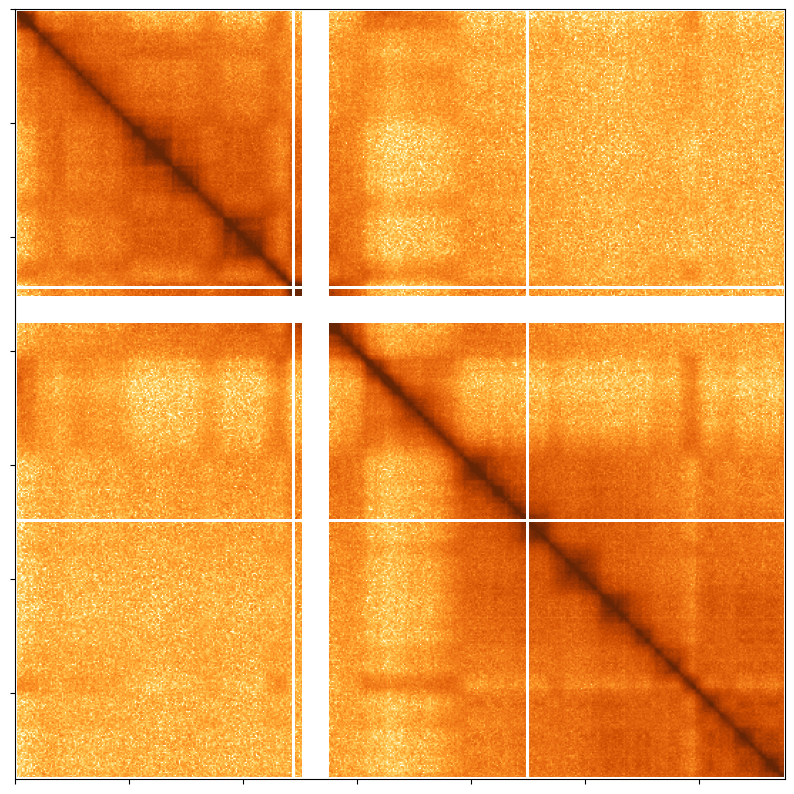

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import gridspec
from matplotlib import colors

import os
import re
import numpy as np
import pandas as pd
import cooler
import sys

cool_name = 'DL-20250326-LCHCSeq-K562-2hPD-DpnII-R2-T1__hg38.hg38.exclude1kb.1000.mcool'
cool_path = '/MyPath/'

# resolution ...
binsize = 250_000
cooler_name_res = f"{cool_name}::/resolutions/{binsize}"
cooler_path_name = os.path.join(cool_path, cooler_name_res)

clr = cooler.Cooler(cooler_path_name)

# getting a symmetric region:
ucsc_region = "chr11"
#chrom = ucsc_region.split(':')[0]
#start = ucsc_region.split(':')[1].split("-")[0]
#end = ucsc_region.split(':')[1].split("-")[1]
matrix = clr.matrix(balance=True).fetch(ucsc_region)

# what's the dynamic range of the matrix,
# i.e. minimal and maxmum values ...
mmin = 0.00000008
mmax = 0.8

# x-axis is basically your colorbar ...
logbins = np.geomspace(0.00008,mmax)

# colormap colors:
vmin = 0.000008
vmax = 0.01

# Create nice ticks for the colorbar

# Calculate the tick between vmin and vmax - geometric mean:
mid_base_bot = np.floor(np.log10(np.sqrt(vmin*vmax)))
mid_base_top = np.ceil(np.log10(np.sqrt(vmin*vmax)))
if vmin < 10**mid_base_bot < vmax:
    vmid = 10**mid_base_bot
    cb_ticks = [vmin, vmid, vmax]
elif vmin < 10**mid_base_top < vmax:
    vmid = 10**mid_base_top
    cb_ticks = [vmin, vmid, vmax]
else:
    cb_ticks = [vmin,vmax]

# figure parameters:
width = 14
height = 10
heatmap_cmap = "YlOrBr" # get more by googling: "colormap matplotlib"
# how to normalize colors/values http://members.cbio.mines-paristech.fr/~nvaroquaux/tmp/matplotlib/users/colormapnorms.html
# try to tweak vmin/vmax to achieve better contrast etc:
color_norm = colors.SymLogNorm(linthresh=mmin,vmin=vmin,vmax=vmax)

# https://matplotlib.org/3.1.0/tutorials/intermediate/imshow_extent.html
origin="upper"
heatmap_extent = [0,clr.chromsizes[ucsc_region],clr.chromsizes[ucsc_region],0]

# create empty figure, aka canvas ...
fig = plt.figure(figsize=(width, height))
# on that figure add new axes:
ax = fig.add_subplot()

img = ax.imshow(matrix, norm = color_norm ,cmap=heatmap_cmap, extent = heatmap_extent,origin=origin)
#cbar = fig.colorbar(img)
#cbar.set_ticks([vmax,vmin])
#cbar.set_ticklabels([vmax,vmin])
#cbar.ax.tick_params(labelsize=13) 

# # deal with ticks and their labels ...
ax.tick_params(bottom=True,labelbottom=False,left=True,labelleft=False,top=False,labeltop=False)
#ax.axes.get_xaxis().set_ticks([])
#ax.axes.get_yaxis().set_ticks([])
# turn float tciks into nice , megabase based ticks
ax.set_xticklabels([f"{int(x/1000000)}" for x in ax.get_xticks()],fontsize=13)
ax.set_yticklabels([f"{int(y/1000000)}" for y in ax.get_yticks()],fontsize=13)

# add x/y labels and tweak their position a bit ...
#ax.set_xlabel("genomic pos., Mb",labelpad=25,fontsize=15)
#ax.set_ylabel("genomic pos., Mb",fontsize=15)
#ax.xaxis.label_position = "top"

fig.savefig(f'{cool_name[:-39 or None]}.{ucsc_region}.{binsize//1000}.kb.png',transparent=True)
cool_name[:-39 or None]

In [ ]:
#### Figure 1c - log2(Observed/exp) zoom heatmap

INFO:root:fallback to serial implementation.
/sharehome/dlafonta/miniconda3/envs/open2c-env/lib/python3.9/site-packages/cooltools/api/expected.py:351: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = dict(iter(bins.groupby("chrom")[clr_weight_name]))


obs_matrix shape: (120, 120), dtype: float64
expected_vals shape: (12383,), dtype: float64


/tmp/ipykernel_1503355/4048569606.py:67: RuntimeWarning: divide by zero encountered in log2
  np.log2(oe_matrix),


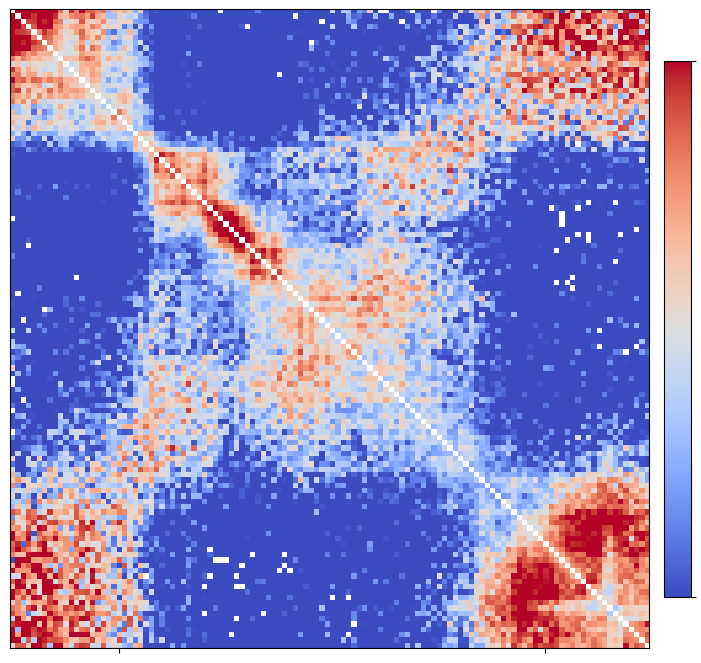

In [4]:
import numpy as np
import cooler
import cooltools
import matplotlib.pyplot as plt
import os
import bioframe

cool_name = 'DL-20250326-LCHCSeq-K562-2hPD-DpnII-R2-T1__hg38.hg38.exclude1kb.1000.mcool'
cool_path = '/MyPath/'

# resolution
binsize = 250_000
cooler_name_res = f"{cool_name}::/resolutions/{binsize}"
cooler_path_name = os.path.join(cool_path, cooler_name_res)
clr = cooler.Cooler(cooler_path_name)

# Specify chromosome and region of interest
chrom = "chr11"
start = 55_000_000  # 50 Mb
end = 85_000_000   # 100 Mb
region = (chrom, start, end) 

# Use bioframe to fetch the genomic features from the UCSC.
hg38_chromsizes = bioframe.fetch_chromsizes('hg38')
hg38_cens = bioframe.fetch_centromeres('hg38')
hg38_arms = bioframe.make_chromarms(hg38_chromsizes, hg38_cens)

# Select only chromosomes that are present in the cooler.
hg38_arms = hg38_arms.set_index("chrom").loc[clr.chromnames].reset_index()

obs_matrix = clr.matrix(balance=True).fetch(region)
# Convert to proper numpy array if needed
obs_matrix = np.array(obs_matrix, dtype=np.float64)

# Create a view_df for just this region
region_df = bioframe.make_viewframe([region])

# Calculate expected only for this region
expected = cooltools.expected_cis(clr, view_df=hg38_arms, nproc=1, ignore_diags=0)

# Extract expected values as a proper 1D numpy array
expected_vals = np.array(expected['balanced.avg.smoothed'].values, dtype=np.float64)

print(f"obs_matrix shape: {obs_matrix.shape}, dtype: {obs_matrix.dtype}")
print(f"expected_vals shape: {expected_vals.shape}, dtype: {expected_vals.dtype}")

# Calculate O/E manually to avoid numba issues
n_bins = obs_matrix.shape[0]
oe_matrix = np.zeros_like(obs_matrix, dtype=np.float64)

for i in range(n_bins):
    for j in range(i, n_bins):
        diag_idx = j - i
        if diag_idx < len(expected_vals) and expected_vals[diag_idx] >= 0:
            oe_matrix[i, j] = obs_matrix[i, j] / expected_vals[diag_idx]
            oe_matrix[j, i] = oe_matrix[i, j]  # Make symmetric
        else:
            oe_matrix[i, j] = np.nan
            oe_matrix[j, i] = np.nan

# Replace any remaining zeros or infinities
oe_matrix[~np.isfinite(oe_matrix)] = np.nan

# Visualization
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(
    np.log2(oe_matrix),
    vmax=1.0,
    vmin=-1.0,
    cmap='coolwarm',
    interpolation='none'
)

# Add colorbar
cb_ticks = [-1, 1]
cbar = plt.colorbar(im, ax=ax, shrink=0.8,pad=0.02)
cbar.set_ticks(cb_ticks)
cbar.set_ticklabels([f'{tick:.1f}' for tick in cb_ticks])
cbar.ax.tick_params(labelsize=25)
cbar.set_ticklabels([]) 
# Convert genomic positions to pixel coordinates
tick_positions_genomic = [60_000_000, 80_000_000]
tick_positions_pixels = [(pos - start) / binsize for pos in tick_positions_genomic]

# Set x-axis ticks at specific positions
ax.set_xticks(tick_positions_pixels)
ax.set_xticklabels([])  

# Remove y-axis ticks
ax.set_yticks([])
ax.set_yticklabels([])

# Show the labels 
# ax.set_xticklabels(['60', '80'])  # or ['60 Mb', '80 Mb']

plt.tight_layout()
plt.show()

fig.savefig(f'{cool_name[:-27 or None]}.{chrom}_{start//1000000}-{end//1000000}Mb.{binsize//1000}.kb.zoom.png',transparent=True)